## Colab 환경에서 실행 시 환경 설정

In [13]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

#### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import koreanize_matplotlib

<hr>

<a id="lecture_index"></a>
# 🔖 ResNet 및 분류 모델 마무리

## 수업 목차
[1. 복습](#one)

[2. VGG 구조 이해 및 구현](#two)
- VGG 모델 특징
- VGG 모델 시각화
- PyTorch로 구현하기

[3. ResNet 개념 및 구현](#three)
- ResNet 모델 특징 
- ResNet 구조 시각화
- 논문 분석
- PyTorch로 구현하기 

[4. 사전학습 모델 활용법](#four)
- 사전학습 모델 개념
- 사전학습 모델 찾는 법
- 사전학습 모델 불러오기
- 사전학습 모델을 활용한 추론

[5. 사전학습 모델 활용 두 가지 방법](#five)
- 전이 학습 
- 제로샷 학습

[6. 분류 모델 미니 프로젝트](#six)
- 데이터 수집 부터 모델 학습까지 

## <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 🧩 Quiz 1

- 이미지 분류

- Alexnet
    1. Dropout
    2. Maxpooling
        - stride = kernel size -> non-overlapping pooling
        - stride < kernel size -> overlapping pooling -> 표현력
    3. relu 도입
        - 기울기 소실 문제 해결
    4. GPU를 처음 사용
    5. Local Response Nomalization

- 과적합을 막기 위해 사용했던 방법들
    1. Dropout
    2. LRN
    3. pooling
    4. 데이터 증강

- 기울기 소실 문제 해결
    1. relu

- 학습 속도 개선, 학습 효율 개선
    1. 가중치 초기화 (가우시안 분포)
    2. 스케줄링

- 데이터 증강 및 전처리
    - 데이터 증강: 고정적이지 않은 변환 (translation, horizontal reflection, PCA로 밝기조절 등이 확률적으로 동작)
    - 전처리: 고정된 변환 / resize를 고정된 (미리 설정한) 비율로 조정
        1. 미리 이미지 사이즈를 전처리 규격에 맞춰서 저장해둠 -> 메모리 효율적, 연산시간 단축

## <a id='two'>2️⃣ VGG구조 이해 및 구현</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ VGG 모델 특징
> VGG는 3x3 Conv 필터를 여러 번 쌓아 깊이를 늘려 성능 향상에 성공한 모델

#### 1️⃣ 3x3 Convolution을 반복해서 깊은 구조 구성
- 모든 Conv Layer는 3x3 필터, padding=1, stride=1 사용
- 여러 개를 쌓으면 receptive field가 커지면서 복잡한 패턴도 포착 가능
- 예: 3x3 2개 = 5x5, 3개 = 7x7 효과

#### 2️⃣ 층이 매우 깊은 CNN 구조
- 총 16개 레이어 (13 Conv + 3 FC)
- 모델이 깊어지면서 정교한 특징 추출 가능

#### 3️⃣ 일관된 구조와 단순한 설계
- 모든 블록이 거의 같은 패턴(Conv x2~3 → MaxPooling)
- 구조가 반복적이고 직관적이어서 구현·확장에 용이

#### 4️⃣ Feature Extractor로 많이 사용
- 단순하고 안정적인 구조 덕분에, 이후 다양한 모델의 백본(backbone)으로 자주 사용됨

#### 5️⃣ 파라미터 수가 매우 많음
- Fully Connected Layer에서 파라미터 수 폭증
- 약 138M(1억 3천만 개) → 연산량이 크고, 메모리 부담도 큼

출처: https://arxiv.org/pdf/1409.1556

### VGG 모델 시각화

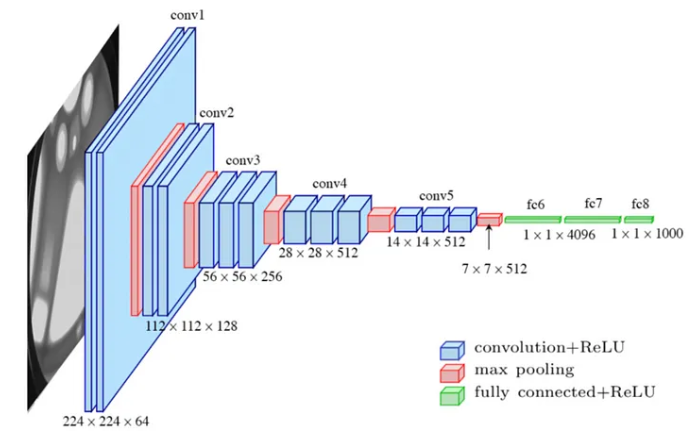

### 논문 분석

#### 용어
> receptive field -> kernel size <br>

#### 데이터 전처리
- Mean substraction (정규화)

#### 데이터 증강
- [Multi-scale traning] 원본 비율 유지한 채로(짧은쪽을 고정하지만 그 길이는 랜덤 선택{256, 384, ...}) Resize -> 랜덤 crop (고정 사이즈)
- Horizontal flip (수평 뒤집기)
- Random RGB Color shift (랜덤하게 밝기 조절)

#### 학습 세부 사항

- batch_size: 256
- SGD
1) momentum: 0.9
2) weight decay: 0.0005
2) learning rate: 0.01 (총 3번 학습률 감소 예정)
- dropout: 0.5
- epoch: 74

### PyTorch로 VGG 구현

In [14]:
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), # 50% 확률로 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), # 밝기, 대비, 채도, 색조 조절
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transform)
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

subset_indices1 = list(range(200))
subset_indices2 = list(range(20))

train_dataset = Subset(train_dataset, subset_indices1)
val_dataset = Subset(val_dataset, subset_indices2)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
image, label = next(iter(train_loader))

In [ ]:
image.shape, label.shape

(torch.Size([128, 3, 224, 224]), torch.Size([128]))

In [15]:
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

def convlayer(in_channels, out_channels, count):
    layer = []
    layer.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1))
    layer.append(nn.BatchNorm2d(out_channels))
    layer.append(nn.ReLU())
    for i in range(count - 1):
        layer.append(nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1))
        layer.append(nn.BatchNorm2d(out_channels))
        layer.append(nn.ReLU())
    layer.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return layer

layer = []
layer += convlayer(3, 64, 2) + convlayer(64, 128, 2) + convlayer(128, 256, 3) + convlayer(256, 512, 3) + convlayer(512, 512, 3)


class Vgg16(nn.Module):
    def __init__(self):
        super(Vgg16, self).__init__()
        self.feature_extractor = nn.Sequential(*layer)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(4096, 10),
        )
        
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x
        
vgg16 = Vgg16()

In [ ]:
vgg16

Vgg16(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), 

In [ ]:
summary(vgg16, input_size=(3, 224, 224), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
             ReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
             ReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [ ]:
import tqdm
import time

In [16]:
import torch
from tqdm import tqdm 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sgd = torch.optim.SGD(lr=0.01, momentum=0.9, weight_decay=0.0005, params=vgg16.parameters())  # SGD: 확률적 경사 하강법
scheduler = torch.optim.lr_scheduler.StepLR(sgd, step_size=30, gamma=0.1)   # step_size: epoch / gamma: learning rate 감소 비율
loss_fn = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc          

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
train_model(vgg16, train_loader, val_loader, loss_fn, sgd, scheduler, epochs=90)

Training:   0%|          | 0/4 [00:00<?, ?it/s]

Validation: 100%|██████████| 1/1 [00:04<00:00,  4.19s/it]


[1/90] Train Loss: 2.3598, Train Acc: 12.00% | Val Loss: 2.3002, Val Acc: 20.00%


Validation: 100%|██████████| 1/1 [00:04<00:00,  4.07s/it]


[2/90] Train Loss: 2.4700, Train Acc: 13.50% | Val Loss: 2.3439, Val Acc: 10.00%


Training:  50%|█████     | 2/4 [01:57<01:57, 58.85s/it]


KeyboardInterrupt: 

## <a id='three'>3️⃣ ResNet 개념 및 구현</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ ResNet 모델 특징
> 배경: 'Layer를 깊게 쌓으면 쌓을 수록 성능이 좋아진다'라는 기대가 있었음. <br> 
> 처음에 16층, 19층, 22층까지 좋은 성능을 보였지만 그 이후 더 깊은 Layer를 쌓는 시도에서 빠질 수 없는 문제가 있었음. <br> 
> 바로 'Gradient Vanishing/Exploding'문제. 이 문제가 발생하지 않더라도 과적합 문제 혹은 성능이 오히려 저하되는 문제가 있었음

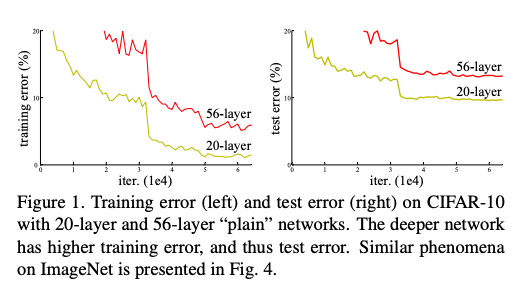

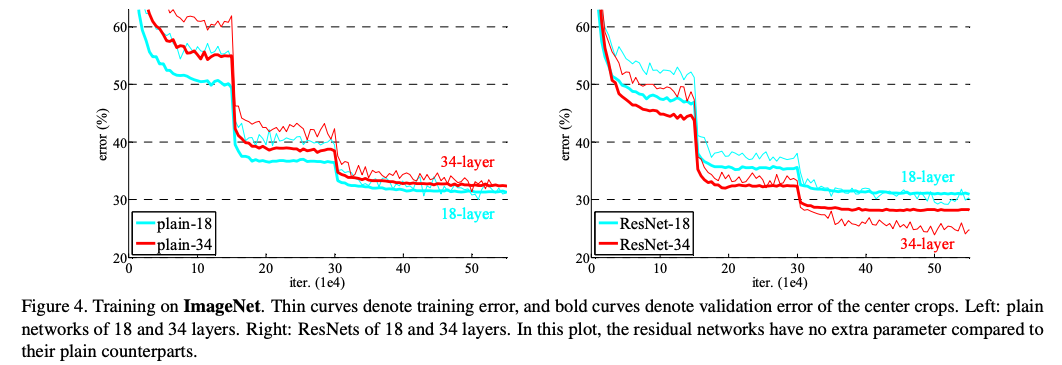

#### 1️⃣ Shortcut connection (Skip connection)
- 이전 층의 계산 결과를 현재 층의 계산 결과와 더해주는 경로 
- 학습을 하면서 layer가 깊어지면서 미분 값이 작아지는 것을 막아주는 방법 

#### 2️⃣ Residual Learning  
- Shortcut connection의 구현으로 입력 x의 일부를 그대로 유지하여 그 다음 레이어에 전달하기 때문에 입력값이 이미 정답과 가까운 상태를 함
- 따라서 좀 더 줄어든 차이(입력값과 출력값의 부족한 차이)를 학습하면 되는 구조로 변환됨 (잔차 학습)

#### 3️⃣ 기존의 CNN 계열의 네트워크보다 훨씬 더 깊어진 네트워크 (34 ~ 152층까지 성공)
- 실험적으로 152층에서도 안정적인 학습 성능을 보여주었음 
- residual learning을 함으로써 layer가 깊어짐에 따라 성능도 비례하여 증가함 

#### 4️⃣ 1x1 Convolution 활용 
- 채널수를 조절하면서 이미지 크기를 절반으로 줄이는 연산 (pooling + 채널 변환 효과)
- 연산량 및 파라미터를 대폭 줄이면서 이미지 크기는 동일하게 유지 -> 비선형적인 표현력 증가, 더 많은 공간 정보 유지
```
ex) 3x3 커널 연산: in_channel=64, out_channel=64, h=54, w=54 
                 => 연산량: 107,495,424 / 파라미터: 36,864
    1x1, 3x3, 1x1 연산(Bottleneck): in_channel=64, out_channel=16 
                                   in_channel=16, out_channel=16
                                   in_channel=16, out_channel=64
                                   => 연산량: 8,218,624 / 파라미터: 4352
```

#### 5️⃣ Adaptive average pooling 활용 
- 입력 사이즈와 출력 사이즈만 알면 자동으로 stride, kernel 사이즈를 지정하여 출력 사이즈 만들어 줌 
- stride = floor(input_size/output_size)
- kernel = input_size - (output_size -1)*stride
- fc layer와 연결하기 쉬움 
- 파라미터 없음 
- 전역적 특징 추출 가능 
- 위치 정보 손실 
- detection, segmentation 같은 문제에서는 활용하는 것에는 주의가 필요 

### ResNet 구조 시각화

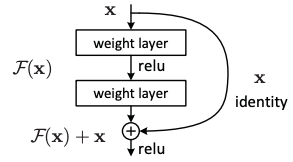

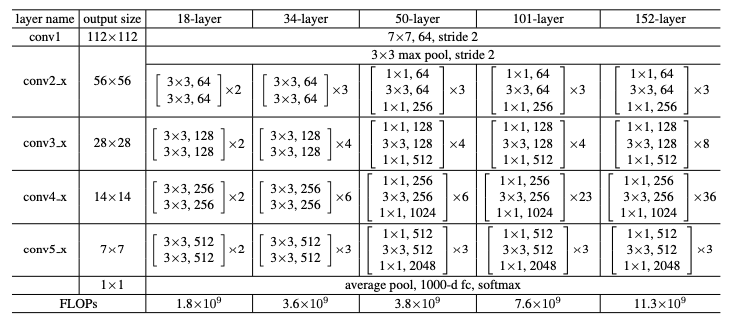

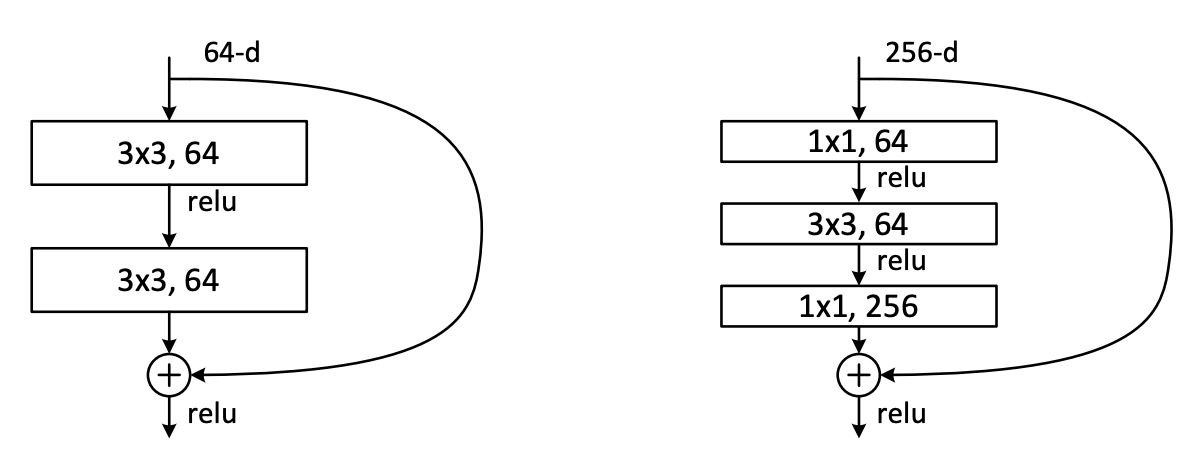

왼쪽: Building block / 오른쪽: bottleneck

구분|Building block | Bottleneck
---|---|---
모델 버전|ResNet-18, ResNet-34|ResNet-50, ResNet-101, ResNet-152
구조|Conv(3x3) -> Conv(3x3)|Conv(1x1) -> Conv(3x3) -> Conv(1x1)
목적|적당한 깊이에서 효과적|깊이를 늘려도 효율적
skip 연결|입력과 출력 shape이 같으면 identity, 다르면 projection||

✅ identity: 입력 그대로 더함 (그대로 내보내는 함수를 identity function이라고함) <br>
✅ projection: 연산이 가능한 형태로 모양을 변환함

In [ ]:
import torch
import torch.nn as nn
import torch.functional as F

# 가중치 초기화
w1 = torch.tensor(0.1, requires_grad=True)
w2 = torch.tensor(0.1, requires_grad=True)
w3 = torch.tensor(0.1, requires_grad=True)
target = torch.tensor(1.0)

# 입력값
x = torch.tensor(0.5)

h1 = F.sigmoid(w1 * x)
h2 = F.sigmoid(w2 * h1)
h3 = F.sigmoid(w3 * h2)

y.backward()
print(w1.grad, w2.grad, w3.grad)  # 각 가중치에 대한 기울기 출력

### Building Block, Bottleneck 구현

In [ ]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BuildingBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.projection = None
        
        if stride != 1 or in_channels != out_channels:
            self.projection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x) # convolution 연산이 텐서를 복사해서 연산함
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.projection is not None:
            out = out + self.projection(identity)
            out = self.relu(out)
            return out
        
        out = self.relu(out + identity)
        return out

In [ ]:
bb = BuildingBlock(64, 64)

In [ ]:
t = torch.randn(1, 64, 54, 54)

In [ ]:
bb(t)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 1.0068, 0.0000, 0.0000],
          [0.0000, 0.0000, 1.9346,  ..., 2.0081, 0.0000, 1.6698],
          [0.8350, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.4000, 0.0000, 0.3652,  ..., 0.0000, 0.5486, 2.3160],
          [2.8716, 2.5448, 0.7207,  ..., 1.0455, 0.0000, 1.2699],
          [0.8039, 0.1682, 0.0000,  ..., 0.9025, 0.0000, 1.3070]],

         [[0.0000, 0.3101, 0.0000,  ..., 0.1863, 0.0000, 0.0000],
          [0.4258, 0.6143, 0.0000,  ..., 0.0440, 2.6767, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 3.8629, 1.3824],
          ...,
          [0.5202, 0.8675, 1.2480,  ..., 1.3708, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0402,  ..., 0.7817, 1.1234, 0.5122],
          [0.0000, 1.2885, 0.0000,  ..., 0.6853, 0.0000, 0.3004]],

         [[1.9015, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.2652],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 3.7779, 1.3231],
          [0.0000, 2.5968, 0.0000,  ..., 0

In [ ]:
bb(t).shape

torch.Size([1, 64, 54, 54])

In [ ]:
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=1, stride=1)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels)
        
        self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        self.projection = None
        
        if stride != 1 or in_channels != out_channels:
            self.projection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
                nn.BatchNorm2d(out_channels)
            ) 
            
    def forward(self, x):
        identity = x
        
        out = self.conv1(x) # convolution 연산이 텐서를 복사해서 연산함
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out) # convolution 연산이 텐서를 복사해서 연산함
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        if self.projection is not None:
            out = out + self.projection(identity)
            out = self.relu(out)
            return out
        
        out = self.relu(out + identity)
        return out
    

In [ ]:
bn = Bottleneck(64, 256)

In [ ]:
bn

Bottleneck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (projection): Sequential(
    (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [ ]:
t = torch.randn(1, 64, 54, 54)

In [ ]:
bn(t).shape

torch.Size([1, 256, 54, 54])

### Shortcut connection의 효과 

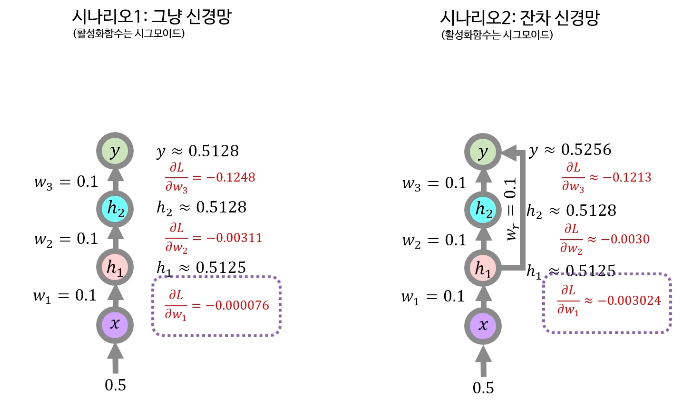

출처: https://www.youtube.com/watch?v=Yf_-bj2Zaq4

### 논문 분석

#### 데이터 전처리 

1. 표준화 (ImageNet 통계값 기준) 

#### 데이터 증강 

1. 짧은 변을 [256, 480] 범위로 랜덤 resize
2. 224x224 랜덤 crop
3. 좌우 반전


#### 학습 세부 사항 

1. batch size: 256
2. Optimizer: SGD
- Momentum (0.9)
- Weight Decay: 0.0001
- Learning Rate: 초기 0.1 → plateau 시 1/10 감소
3. 90 epoch
4. Batch Normalization (Conv 연산 다음 / 활성화 함수 연산 전)

### PyTorch 구현

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

In [ ]:
class ResNet50(nn.Module):
    def __init__(self):
        super(ResNet50, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, stride=2, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        
        self.bn1 = Bottleneck(64, 256) # 56*56
        self.bn2 = Bottleneck(256, 256) # 56*56
        self.bn3 = Bottleneck(256, 256) # 56*56
        
        self.bn4 = Bottleneck(256, 512, stride=2) # 28*28
        self.bn5 = Bottleneck(512, 512) # 28*28
        self.bn6 = Bottleneck(512, 512) # 28*28
        self.bn7 = Bottleneck(512, 512) # 28*28
        
        self.bn8 = Bottleneck(512, 1024, stride=2) # 14*14
        self.bn9 = Bottleneck(1024, 1024) # 14*14
        self.bn10 = Bottleneck(1024, 1024) # 14*14
        self.bn11 = Bottleneck(1024, 1024) # 14*14
        self.bn12 = Bottleneck(1024, 1024) # 14*14
        self.bn13 = Bottleneck(1024, 1024) # 14*14
        
        self.bn14 = Bottleneck(1024, 2048, stride=2) # 7*7
        self.bn15 = Bottleneck(2048, 2048) # 7*7
        self.bn16 = Bottleneck(2048, 2048) # 7*7
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # 7*7 -> 1*1
        self.flatten = nn.Flatten(0, -1)
        self.fc = nn.Linear(2048, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.bn2(x)
        x = self.bn3(x)
        x = self.bn4(x)
        x = self.bn5(x)
        x = self.bn6(x)
        x = self.bn7(x)
        x = self.bn8(x)
        x = self.bn9(x)
        x = self.bn10(x)
        x = self.bn11(x)
        x = self.bn12(x)
        x = self.bn13(x)
        x = self.bn14(x)
        x = self.bn15(x)
        x = self.bn16(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)
        
        return x


In [ ]:
t = torch.randn(2048, 7, 7)
avg = nn.AdaptiveAvgPool2d((1, 1))
fc = nn.Linear(2048, 1000)
flat = nn.Flatten(0, -1)

In [ ]:
a = avg(t)
a.shape
fc(a.squeeze(1, 2))
fc(flat(a))

tensor([ 1.5157e-02, -3.2866e-02, -5.2343e-02,  1.3628e-02, -1.0339e-02,
         5.9034e-02, -6.1766e-02,  1.3613e-01, -4.2447e-03, -4.5081e-03,
         5.8140e-02, -1.1228e-01,  1.6825e-01,  9.6783e-02,  9.7083e-03,
        -5.8738e-02, -4.0866e-02,  1.4000e-01,  1.4583e-01, -9.6999e-03,
        -2.3025e-02, -1.2066e-02,  9.7976e-02, -1.1245e-03,  1.1573e-01,
         2.5607e-04,  1.1856e-01,  2.9912e-02, -1.5245e-01,  1.3759e-02,
        -1.2586e-01, -8.4657e-02, -9.8646e-02, -2.0340e-01, -4.2150e-02,
        -1.6451e-01,  5.5863e-03,  5.9382e-02, -4.4171e-02, -9.7739e-02,
        -4.9832e-02, -9.3999e-02,  1.3872e-01, -2.0038e-02, -1.6881e-02,
         4.9007e-02, -8.2722e-02,  6.7353e-02, -7.0838e-02,  3.9951e-02,
        -1.2563e-01,  1.4522e-02,  9.9655e-02, -1.9670e-01, -1.5069e-02,
        -8.9222e-02, -6.5303e-02, -9.9758e-02,  6.9057e-02,  4.1694e-02,
         1.9088e-02, -3.3463e-02,  1.3134e-01,  4.3631e-02,  2.1551e-02,
        -5.0274e-02, -1.8588e-01,  1.1248e-02,  9.3

In [ ]:
a.view(a.size(1), -1)

tensor([[-0.0840,  0.2541, -0.0241,  ..., -0.0019,  0.0886, -0.1443]])

## <a id='four'>4️⃣ 사전학습 모델 활용법</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 사전학습 모델

> 사전학습 모델(pre-trained model)은 대규모 데이터로 사전에 학습된 신경망 모델 <br>
> 일반적으로 이 모델들은 특정 작업이나 데이터셋에 최적화되기 전에, 일반적인 패턴이나 특징을 학습함

참고: https://pytorch.org/vision/stable/models.html

### 사전학습 모델 찾는 법

In [ ]:
from timm import list_models # pip install timm

all_models = list_models()

d:\anaconda\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 사전학습 모델 불러오기

In [ ]:
# @title
import pandas as pd
data = {
    "항목": [
        "목적", "결과", "가중치 적용", "전처리 접근", "유용한 상황", "활용 추천", "유연성",
    ],
    "get_model()": [
        "모델 구조 + 가중치 로딩",
        "nn.Module",
        '"DEFAULT" or Enum 지정',
        ".transforms() 가능",
        "표준적이고 깔끔한 사용",
        "⭐⭐⭐⭐⭐",
        "🟡 중간",
    ],
    "get_weight()": [
        "가중치 enum 객체만 가져옴",
        "Weights Enum 객체",
        "적용은 직접 해야 함",
        ".transforms() 포함",
        "가중치가 언제, 어떻게 학습되었는지 자세한 정보가 필요할 때",
        "⭐⭐⭐⭐☆",
        "🔴 낮음",
    ],
    "get_model_weights()": [
        "모델의 가중치 enum 목록 조회",
        "Enum 리스트",
        "적용은 직접 해야 함",
        "각 enum에 대해 접근 가능",
        "여러 가중치 비교 시",
        "⭐⭐⭐☆☆",
        "❌ 매우 낮음",
    ],
    "torch.hub.load()": [
        "GitHub 저장소에서 불러오기",
        "nn.Module",
        "weights='enum 단, 저장소마다 기본 가중치는 다름",
        "직접 구현 필요",
        "외부 논문/커스텀 모델 사용",
        "⭐⭐☆☆☆",
        "🚀 매우 높음",
    ],
    "클래스 방식 (models.resnet18)": [
        "모델 클래스 직접 불러오기",
        "nn.Module",
        "weights='enum'",
        "대부분 수동 구현",
        "기존 코드를 그대로 따라하거나 특정 레이어만 간단하게 수정해서 쓸 때",
        "⭐⭐⭐☆☆",
        "🟠 약간 높음",
    ],
    "Hugging Face 방식": [
        "Transformer, ViT 등 최신 모델 로딩",
        "HuggingFace 모델 객체",
        ".from_pretrained()",
        "자동 제공 (tokenizer 등)",
        "최신 모델을 불러오거나 바로 추론하거나 fine-tuning을 하고 싶을 때",
        "⭐⭐⭐⭐☆",
        "🟢 높음",
    ]
}
df1 = pd.DataFrame(data)

In [ ]:
# @title
import plotly.graph_objects as go # pip install plotly / pip install --upgrade nbformat

def show_table(df, width, height):
    header = list(df.columns)
    cells = [df[col] for col in df.columns]

    fig = go.Figure(data=[go.Table(
        header=dict(values=header, fill_color='paleturquoise', align='left'),
        cells=dict(values=cells, fill_color='lavender', align='left'))
    ])

    fig.update_layout(
        autosize=True,
        margin=dict(l=10, r=10, t=10, b=10),
        width=width,
        height=height
    )
    fig.show()

In [ ]:
show_table(df1, 1000, 350)

✅ enum
```
:정해진 값 외에는 바뀌지 않는 이름들의 집합
여기서 말하는 enum은 모델의 이름 집합
ex) vgg16, resnet50 등...
```

```
⭐⭐⭐⭐⭐: 실무, 연습 모두 추천 (공식 표준)
⭐⭐⭐⭐: 추천하는 방식이지만 약간의 제약/주의가 필요
⭐⭐⭐: 상황에 따라 쓰면 유용. 보조용으로 적합
⭐⭐: 고급 사용자에게 추천. 문서나 코드 구조를 분석할 수 있는 경우 사용
```

In [ ]:
from torchvision.models import get_model, get_weight, get_model_weights, resnet50, ResNet50_Weights

vgg16 = get_model("vgg16", weights=None)
pretrained_vgg16 = get_model("vgg16", weights="DEFAULT")

resnet50_enum = get_weight('ResNet50_Weights.DEFAULT') # ResNet50_Weights.DEFAULT와 동일 (Enum 객체)

# accuracy 76.130%
resnet1 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
# accuracy 80.858%
resnet2 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# 기본 모델 (IMAGENET1K_V2와 동일)
resnet3 = resnet50(weights=ResNet50_Weights.DEFAULT)
# 문자열로도 설정 가능
resnet4 = resnet50(weights="IMAGENET1K_V2")
# 랜덤으로 초기화된 모델 (사전학습 모델 X)
resnet5 = resnet50(weights=None)

AttributeError: type object 'torch._C._distributed_c10d.ProcessGroup' has no attribute 'Options'

In [ ]:
# repo_or_dir: Github 주소 + 태그(버전)
# model: 모델 이름
# force_reload=True -> 캐시된 모델을 가져오지 않고 최신으로 가져옴
# trust_repo: pytorch 저장소가 아닌 다른 저장소로 부터 다운 받을 때 사용
# 단, github 저장소 안에 hubconf.py 파일이 있는 경우만 다운로드 가능
resnet18 = torch.hub.load("pytorch/vision:v0.14.0", "resnet18")

NameError: name 'torch' is not defined

### 전처리 방식은 언제 적용해야 하는 걸까?

In [ ]:
# @title
data = {
    "상황": [
        "모델 학습 (train)",
        "모델 추론 (inference)",
        "fine-tuning (사전학습 모델 재학습)",
        "feature 추출 용도"
    ],
    "전처리 필요 여부": [
        "🟢 꼭 필요",
        "🟢 꼭 필요",
        "🟠 필요",
        "🟠 필요"
    ],
    "이유": [
        "원래 데이터는 다양한 크기/범위를 가지므로 정규화, 리사이즈 필요",
        "학습과 동일한 데이터 분포로 넣어야 예측이 정확함",
        "base 모델이 학습한 데이터 분포 유지 필요",
        "전처리 안 하면 feature space가 일치하지 않음"
    ]
}

df2 = pd.DataFrame(data)

NameError: name 'pd' is not defined

In [ ]:
show_table(df2, 1000, 170)

#### 🛠️ Feature space
> 가중치에 의해 정의되는 feature map의 숫자 공간 <br>
> 쉽게 말해, 데이터를 이해하는 방식을 모아 놓은 공간

### 꼭 필요는 뭐고 필요는 뭘까?

> fine-tuning 또는 feature 추출을 할 때도 전처리는 필수지만, 데이터 증강 처리는 필수 보다는 선택 쪽에 가깝다

### 모델 불러오기, 전처리 찾기 너무 불편한데 한 번에 하는 방법은 없나?

In [ ]:
from torchvision.models import get_model, get_weight

def load_model_with_transform(model_name, weight_name = "DEFAULT"):
    pass

AttributeError: module 'torch' has no attribute 'no_grad'

### 사전학습 모델을 활용한 추론

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('사진/goldfish2.jpeg')

## <a id='five'>5️⃣ 사전학습 모델을 활용한 전이학습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 전이학습 (Transfer Learning)
> 사전학습된 모델의 가중치나 구조를 활용하여, 새로운 데이터 셋에 맞춰 모델을 재학습 하는 방법 

#### 👆 특징 추출 (Feature Extraction)
> 사전학습된 모델의 상위 레이어를 사용해 새로운 데이터 셋에서 유용한 특징을 추출하고 마지막 레이어를 바꿔 새로운 작업을 수행하는 방법 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torchvision.models import get_model, get_weight, get_model_weights
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

In [ ]:
# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 사전학습된 모델 찾기 
vggs = get_model_weights('vgg16')

## 디버깅

#### 학습 루프 밖에서 디버깅

In [18]:
def debug_nan(model, inputs, targets):
    outputs = model(inputs)

    print("Outputs contain NaN: ", torch.isnan(outputs).any().item())
    
    print("Prediction dtype: ", outputs.dtype)
    print("Sample Prediction: ", outputs[:5])
    
    print("Targets dtype: ", targets.dtype)
    print("Sample targets: ", targets[:5])
    
    loss_fn = nn.CrossEntropyLoss()
    loss = loss_fn(outputs, targets)
    print("Loss value: ", loss.item())

inputs, targets = next(iter(train_loader))
inputs, targets = inputs.to(device), targets.to(device)

#### 학습 도중 디버깅

In [ ]:
class NaNDebbuger:
    def __init__(self, model, verbose=True):
        self.model = model
        self.verbose = verbose

    def check_loss(self, loss, outputs=None, targets=None, mode=None, step=None):
        pass
    def check_input(self, inputs=None, mode=None, step=None): 
        pass

### 중간 출력값 디버깅

#### ✌️ 미세 조정 (Fine-tuning)
> 전체 레이어의 파라미터를 다시 재학습 하거나 일부 레이어를 제외하여, 새로운 데이터 셋을 잘 예측 할 수 있도록 학습하는 방법

In [23]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 사전학습된 VGG16 모델 불러오기
model = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')

In [29]:
# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 사전학습된 모델 찾기
vgg16_enum = get_weight('VGG16_Weights.IMAGENET1K_V1') # VGG16_Weights.IMAGENET1K_V1와 동일 (Enum 객체)

# 전처리
transfrom = vgg16_enum.transforms()

# 2. 모델 불러오기
vgg = models.vgg16(weights=vgg16_enum.IMAGENET1K_V1) # VGG16_Weights.IMAGENET1K_V1와 동일 (Enum 객체)

# 3. 모델에서 feature extractor에 해당하는 layer의 미분값을 구하지 못하게 고정
for param in vgg.features.parameters():
    param.requires_grad = False # 미분값을 구하지 못하도록 설정
    
# 4. 출력층을 내가 원하는대로 수정
vgg.classifier[6] = nn.Linear(4096, 10) # 10개의 클래스로 분류하도록 수정

# 5. 옵티마이저, 손실함수, 스케줄러 등...
optimizer = optim.Adam(vgg.classifier[6].parameters(), lr=0.001) # 수정한 출력층의 파라미터만 업데이트
loss_fn = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=10, gamma=0.1) # 10 epoch마다 learning rate를 0.1배로 감소

# 6. 데이터셋 불러오기


# 전처리
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), # 50% 확률로 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), # 밝기, 대비, 채도, 색조 조절
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# subset_indices1 = list(range(200))
# subset_indices2 = list(range(20))

# train_dataset = Subset(train_dataset, subset_indices1)
# val_dataset = Subset(val_dataset, subset_indices2)
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 7. 훈련 함수
import torch
from tqdm import tqdm 

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc          

In [30]:
train_model(vgg, train_loader, val_loader, loss_fn, optimizer, scheduler, epochs=90)

Training:   3%|▎         | 13/391 [05:12<2:31:17, 24.01s/it]


KeyboardInterrupt: 

## <a id='six'>6️⃣ 분류 모델 미니 프로젝트</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>